In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
balance_data = {
    "Item": [
        "Total Assets",
        "Current Assets",
        "Non-Current Assets",
        "Total Liabilities",
        "Equity"
    ],
    "2019": [
        1343910,
        985312,
        358598,
        1006742,
        337168
    ],
    "2020": [
        1937424,
        1118672,
        818752,
        1459760,
        477664
    ]
}

balance_df = pd.DataFrame(balance_data)

balance_df["Change"] = balance_df["2020"] - balance_df["2019"]
balance_df["Change (%)"] = (balance_df["Change"] / balance_df["2019"]) * 100

balance_df

,Item,2019,2020,Change,Change (%)
0,Total Assets,1343910,1937424,593514,44.163225
1,Current Assets,985312,1118672,133360,13.534799
2,Non-Current Assets,358598,818752,460154,128.320292
3,Total Liabilities,1006742,1459760,453018,44.998421
4,Equity,337168,477664,140496,41.669435


In [19]:
debt_ratio_2019 = 1006742 / 1343910
debt_ratio_2020 = 1459760 / 1937424

print("Debt Ratio 2019:", debt_ratio_2019)
print("Debt Ratio 2020:", debt_ratio_2020)

Debt Ratio 2019: 0.7491141519893445
Debt Ratio 2020: 0.7534540709725904


In [21]:
equity_ratio_2019 = 337168 / 1343910
equity_ratio_2020 = 477664 / 1937424

print("Equity Ratio 2019:", equity_ratio_2019)
print("Equity Ratio 2020:", equity_ratio_2020)

Equity Ratio 2019: 0.2508858480106555
Equity Ratio 2020: 0.2465459290274096


In [23]:
profit_margin_2019 = 100774 / 2352850
profit_margin_2020 = 107887 / 2862882

print("Profit Margin 2019:", profit_margin_2019)
print("Profit Margin 2020:", profit_margin_2020)

Profit Margin 2019: 0.042830609686125336
Profit Margin 2020: 0.0376847526373773


In [25]:
ratio_df = pd.DataFrame({
    "Ratio": ["Debt Ratio", "Equity Ratio", "Profit Margin"],
    "2019": [debt_ratio_2019, equity_ratio_2019, profit_margin_2019],
    "2020": [debt_ratio_2020, equity_ratio_2020, profit_margin_2020]
})

ratio_df

,Ratio,2019,2020
0,Debt Ratio,0.749114,0.753454
1,Equity Ratio,0.250886,0.246546
2,Profit Margin,0.042831,0.037685


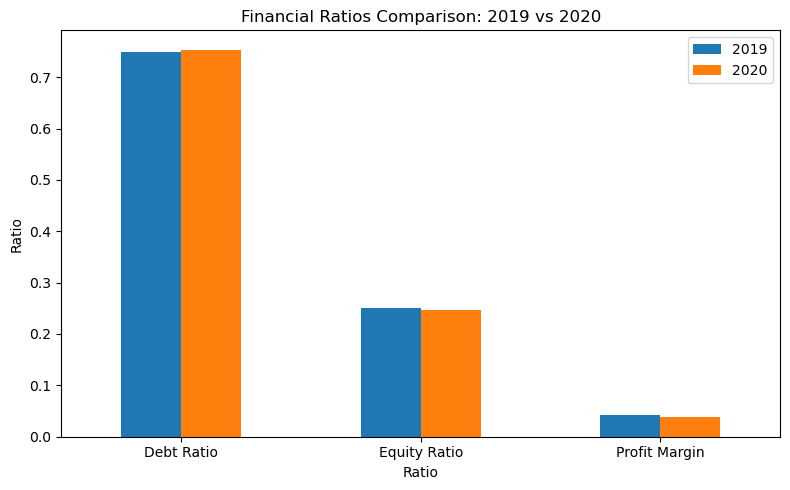

In [27]:
ratio_df.set_index("Ratio").plot(kind="bar", figsize=(8,5))

plt.title("Financial Ratios Comparison: 2019 vs 2020")
plt.ylabel("Ratio")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
sector_df = pd.DataFrame(sector_data)

sector_df

,Metric,2019,2020
0,EU Total Imports (Billion €),338.2,1300.0
1,EU Imports from Turkey (Billion €),13.3,45.0
2,Turkey Share (%),3.9,3.6


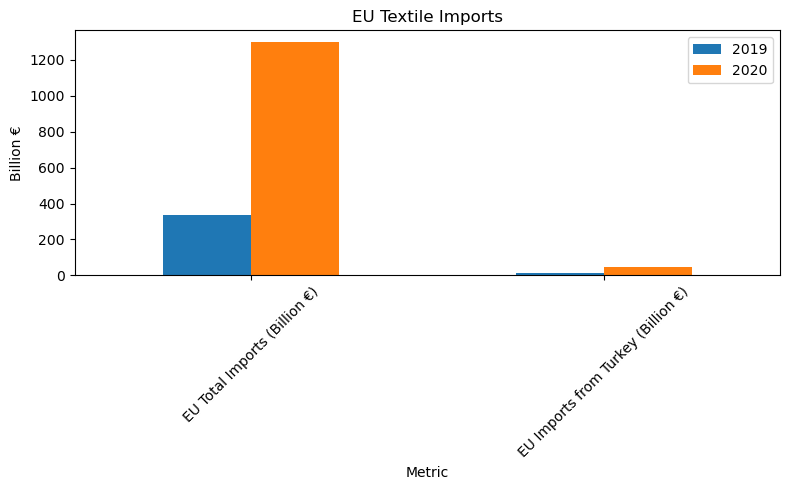

In [37]:
import matplotlib.pyplot as plt

imports_df = sector_df.iloc[0:2]

imports_df.set_index("Metric")[["2019","2020"]].plot(kind="bar", figsize=(8,5))

plt.title("EU Textile Imports")
plt.ylabel("Billion €")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

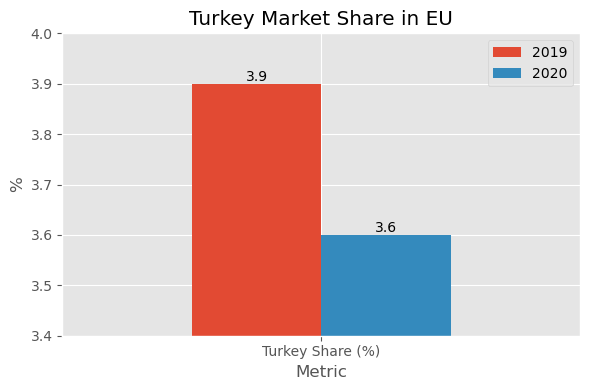

In [47]:
ax = share_df.set_index("Metric")[["2019","2020"]].plot(kind="bar", figsize=(6,4))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("Turkey Market Share in EU")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.ylim(3.4, 4.0)

plt.tight_layout()
plt.show()

Turkey’s market share in the EU textile sector slightly declined from 3.9% to 3.6% during the COVID-19 period. While the decrease is relatively small, it reflects the broader contraction in global demand and increased competition during the pandemic.

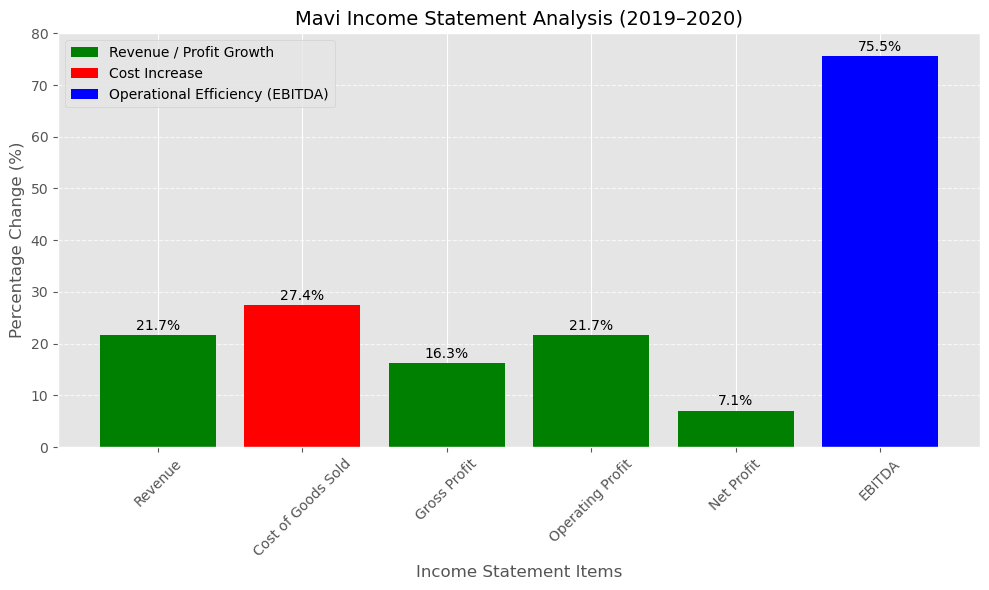

In [68]:
plt.style.use("ggplot")
plt.figure(figsize=(10, 6))

bars = plt.bar(income_df["Item"], income_df["Plot Value"], color=colors)

# labels
for i, v in enumerate(income_df["Percentage Change (%)"]):
    plt.text(i, income_df["Plot Value"][i] + 1, f"{v:.1f}%", ha='center')

plt.title("Mavi Income Statement Analysis (2019–2020)", fontsize=14)
plt.xlabel("Income Statement Items")
plt.ylabel("Percentage Change (%)")

plt.xticks(rotation=45)
plt.ylim(0, 80)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("mavi_income_statement_analysis.png", dpi=300, bbox_inches='tight')

plt.show()

The analysis indicates that Mavi maintained strong financial performance during the COVID-19 period. Despite a significant increase in cost of goods sold, the company achieved solid revenue growth, leading to improvements in gross and operating profit.

The most notable outcome is the substantial increase in EBITDA (75.5%), highlighting improved operational efficiency. Overall, Mavi demonstrated resilience and effective cost management during a period of global economic disruption.

In [71]:
# ==============================
# PREPARE DATA FOR HEATMAP
# ==============================
heatmap_df = income_df[["2019", "2020"]].T

# sütun isimlerini metric yap
heatmap_df.columns = income_df["Item"]

heatmap_df

Item,Revenue,Cost of Goods Sold,Gross Profit,Operating Profit,Net Profit,EBITDA
2019,2352850,-1144905,1207945,297472,100774,367130
2020,2862882,-1458268,1404614,362002,107887,644390


In [73]:
# ==============================
# CALCULATE CORRELATION
# ==============================
corr = heatmap_df.corr()

corr

Item,Revenue,Cost of Goods Sold,Gross Profit,Operating Profit,Net Profit,EBITDA
Item,,,,,,
Revenue,1.0,-1.0,1.0,1.0,1.0,1.0
Cost of Goods Sold,-1.0,1.0,-1.0,-1.0,-1.0,-1.0
Gross Profit,1.0,-1.0,1.0,1.0,1.0,1.0
Operating Profit,1.0,-1.0,1.0,1.0,1.0,1.0
Net Profit,1.0,-1.0,1.0,1.0,1.0,1.0
EBITDA,1.0,-1.0,1.0,1.0,1.0,1.0


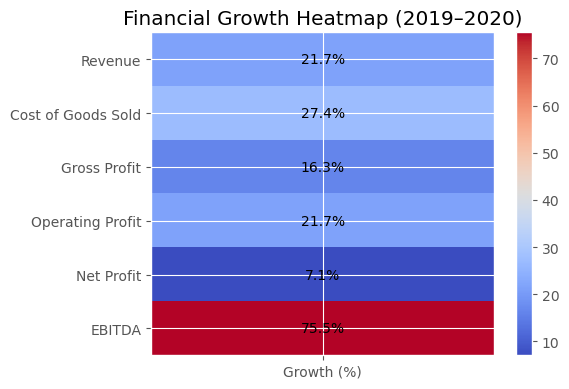

In [77]:
# Better heatmap (growth-based)
growth_df = income_df.set_index("Item")[["Percentage Change (%)"]]

plt.figure(figsize=(6,4))
plt.imshow(growth_df, cmap='coolwarm', aspect='auto')

plt.colorbar()

plt.yticks(range(len(growth_df.index)), growth_df.index)
plt.xticks([0], ["Growth (%)"])

for i in range(len(growth_df.index)):
    plt.text(0, i, f"{growth_df.iloc[i, 0]:.1f}%", ha='center', va='center')

plt.title("Financial Growth Heatmap (2019–2020)")

plt.tight_layout()
plt.show()

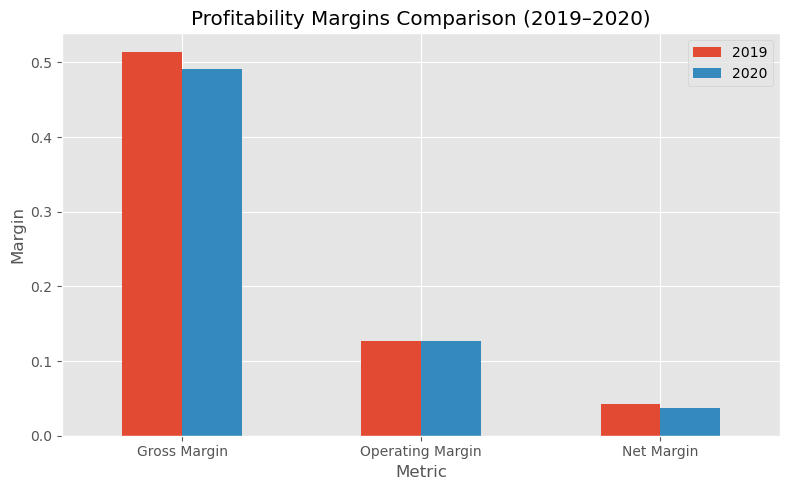

In [79]:
# ==============================
# CALCULATE MARGINS
# ==============================
margin_df = pd.DataFrame({
    "Metric": ["Gross Margin", "Operating Margin", "Net Margin"],
    "2019": [
        1207945 / 2352850,
        297472 / 2352850,
        100774 / 2352850
    ],
    "2020": [
        1404614 / 2862882,
        362002 / 2862882,
        107887 / 2862882
    ]
})

# plot
margin_df.set_index("Metric").plot(kind="bar", figsize=(8,5))

plt.title("Profitability Margins Comparison (2019–2020)")
plt.ylabel("Margin")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

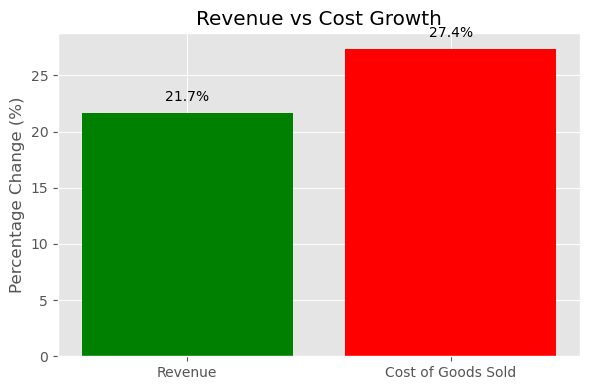

In [81]:
comparison_df = income_df[income_df["Item"].isin(["Revenue", "Cost of Goods Sold"])]

plt.figure(figsize=(6,4))
plt.bar(comparison_df["Item"], comparison_df["Percentage Change (%)"], color=["green", "red"])

plt.title("Revenue vs Cost Growth")
plt.ylabel("Percentage Change (%)")

for i, v in enumerate(comparison_df["Percentage Change (%)"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

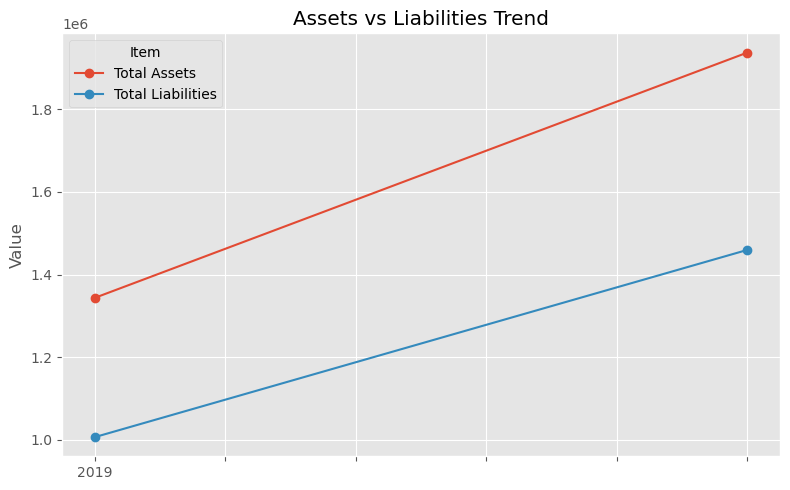

In [83]:
balance_simple = balance_df[balance_df["Item"].isin(["Total Assets", "Total Liabilities"])]

balance_simple.set_index("Item")[["2019","2020"]].T.plot(figsize=(8,5), marker='o')

plt.title("Assets vs Liabilities Trend")
plt.ylabel("Value")

plt.grid(True)
plt.tight_layout()
plt.show()

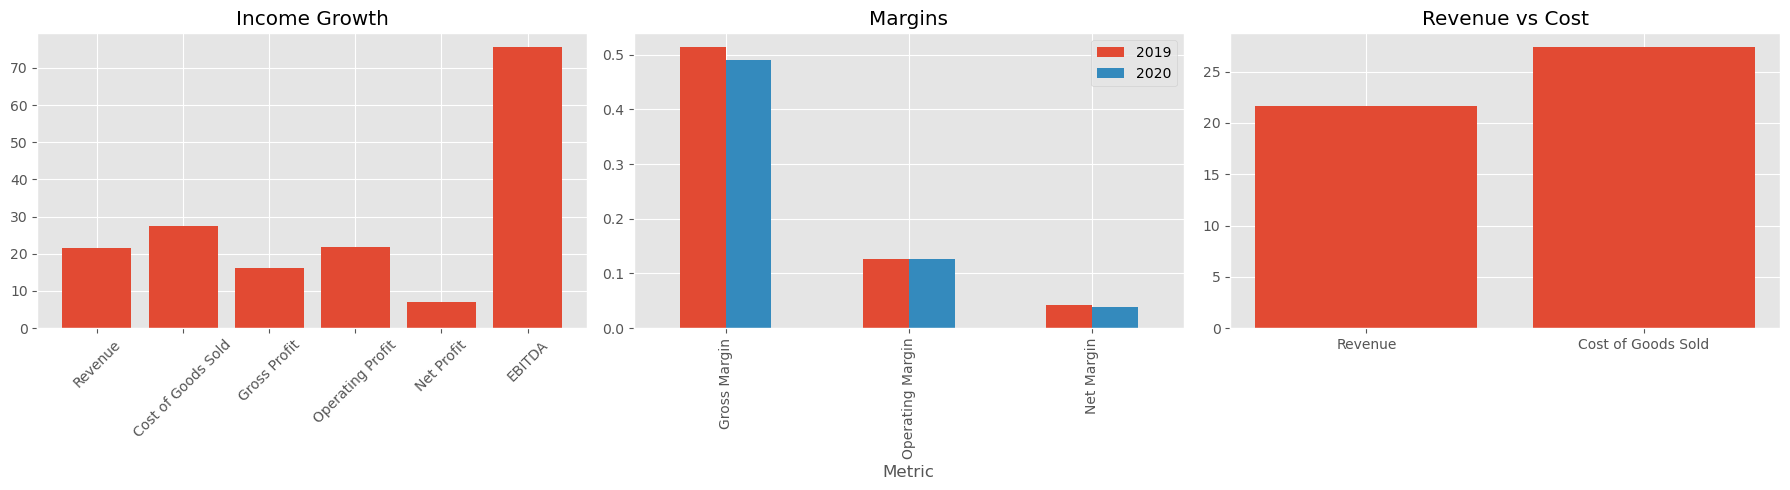

In [85]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# 1. Income growth
axs[0].bar(income_df["Item"], income_df["Plot Value"])
axs[0].set_title("Income Growth")
axs[0].tick_params(axis='x', rotation=45)

# 2. Margins
margin_df.set_index("Metric").plot(ax=axs[1], kind="bar")
axs[1].set_title("Margins")

# 3. Revenue vs Cost
axs[2].bar(comparison_df["Item"], comparison_df["Percentage Change (%)"])
axs[2].set_title("Revenue vs Cost")

plt.tight_layout()
plt.show()